In [2]:
library(splines2)
fitdist2 <-
  function(vals, probs, lower = -Inf,
           upper = Inf, weights = 1, tdf = 3,
           expertnames = NULL,
           excludelogt = FALSE){

ERROR: Error in parse(text = x, srcfile = src): <text>:7:0: unexpected end of input
5:            expertnames = NULL,
6:            excludelogt = FALSE){
  ^


In [1]:
vals<-c(10, 15, 20, 25, 30, 35, 40, 45)
probs<-c(0.03333333, 0.10000000, 0.20000000, 0.36666667, 0.60000000, 0.76666667, 0.90000000, 0.96666667)

In [2]:
lower=1
upper=100
weights = 1
tdf = 3
expertnames = NULL
excludelogt = FALSE

In [66]:
if(is.matrix(vals)==F){vals<-matrix(vals, nrow = length(vals), ncol = 1)}
    if(is.matrix(probs)==F){probs <- matrix(probs, nrow = nrow(vals), ncol = ncol(vals))}
    
    
    if(is.matrix(weights)==F){weights <- matrix(weights, nrow = nrow(vals), ncol = ncol(vals))}
    if(length(lower)==1){lower <- rep(lower, ncol(vals))}
    if(length(upper)==1){upper <- rep(upper, ncol(vals))}
    if(length(tdf)==1){tdf <- rep(tdf, ncol(vals))}
    
    n.experts <- ncol(vals)
    normal.parameters <- matrix(NA, n.experts, 2)
    skewnormal.parameters <- matrix(NA, n.experts, 3)
    tParameters <- matrix(NA, n.experts, 3)
    mirrorgamma.parameters <- gamma.parameters <- 
      matrix(NA, n.experts, 2)
    mirrorlognormal.parameters <- 
      lognormal.parameters <- matrix(NA, n.experts, 2)
    mirrorlogt.parameters <- logt.parameters <-
      matrix(NA, n.experts, 3)
    beta.parameters <- matrix(NA, n.experts, 2)
    ssq<-matrix(NA, n.experts, 11)
    notes <- NULL

In [71]:
probs[,1]

[1] 0.03333333 0.10000000 0.20000000 0.36666667 0.60000000 0.76666667 0.90000000
[8] 0.96666667

In [7]:
    colnames(ssq) <- c("normal", "t", "skewnormal",
                       "gamma", "lognormal", "logt", 
                      "beta", 
                       "mirrorgamma",
                       "mirrorlognormal",
                       "mirrorlogt","bspline")
    
    
    if(n.experts > 1 & n.experts < 27 & is.null(expertnames)){
      expertnames <- paste("expert.", LETTERS[1:n.experts], sep="")
    }
    
    if(n.experts > 27 & is.null(expertnames)){
      expertnames <- paste("expert.", 1:n.experts, sep="")
    }
    
    limits <- data.frame(lower = lower, upper = upper)
    row.names(limits) <- expertnames

In [8]:
i=1

In [9]:

      if (length(probs[, i]) < 1){stop("need at least one elicited probability")}
      if (min(probs[,i]) < 0 | max(probs[,i]) > 1 ){stop("probabilities must be between 0 and 1")}
      if (min(vals[,i]) < lower[i]){stop("elicited parameter values cannot be smaller than lower parameter limit")}
      if (max(vals[,i]) > upper[i]){stop("elicited parameter values cannot be greater than upper parameter limit")}
      if (tdf[i] <= 0 ){stop("Student-t degrees of freedom must be greater than 0")}
      

In [10]:
      # Need to exclude any probability judgements
      # P(X<=x) = 0 or P(X<=x) = 1
      # Facilitator should enforce these probabilities via the parameter limits  
      
      inc <- (probs[, i] > 0) & (probs[, i] < 1)
      if(sum(inc) < 1){stop("need at least one probability between 0 and 1")}
      minprob <- min(probs[inc, i])
      maxprob <- max(probs[inc, i])
      minvals <- min(vals[inc, i])
      maxvals <- max(vals[inc, i])

In [11]:
min(vals[-1,i] - vals[-nrow(vals),i])<= 0

[1] FALSE

In [12]:
q.fit <- approx(x = probs[inc,i], y = vals[inc,i],
                      xout = c(0.4, 0.5, 0.6))$y

In [13]:
q.fit

[1] 25.71429 27.85714 30.00000

In [14]:
l <- q.fit[1] # estimated 40th percentile on original scale
      u <- q.fit[3] # estimated 60th percentile on original scale
      
     # if(minprob > 0 & maxprob < 1){
        
        minq <- qnorm(minprob)
        maxq <- qnorm(maxprob)

In [15]:
   
        minq <- qnorm(minprob)
        maxq <- qnorm(maxprob)
        # Estimate m and v assuming X~N(m,v)
        
        # Obtain m by solving simultaneously:
        # m + Z_l \sqrt{v} = X_l
        # m + Z_u \sqrt{v} = X_u
        # where Z_a is a-th quantile from N(0, 1), X_a is a-th quantile of X
        m <- (minvals * maxq - maxvals * minq) / (maxq - minq)
        v <- ((maxvals - minvals) / (maxq - minq))^2
        
        # mlog used for lognormal
        mlog <- (log(minvals - lower[i]) * 
                   maxq - log(maxvals - lower[i]) * minq) /
          (maxq - minq)
        
        # mlog used for mirror lognormal
        mlogMirror <- (log(upper[i] - maxvals) * 
                         (1 - minq) -
                         log(upper[i] - minvals) * (1-maxq)) /
          (maxq - minq)

In [19]:
### So this gets the fit, but it is based on the parameters, which are already calculated
source("normal.error.r")
normal.fit <- optim(c(m, 0.5*log(v)), 
                          normal.error, values = vals[inc,i], 
                          probabilities = probs[inc,i], 
                          weights = weights[inc,i])   
      normal.parameters[i,] <- c(normal.fit$par[1], exp(normal.fit$par[2]))
      ssq[i, "normal"] <- normal.fit$value
      

In [20]:
exp(0.5*log(v))

[1] 9.542429

In [21]:
normal.parameters

27.90163,9.520439


In [45]:
source("normal.error.r")

In [22]:
library("splines")

In [23]:
spline_fit <- smooth.spline(probs[inc, i], vals[inc, i], spar = 0.7)

In [26]:
cdf_values <- predict(spline_fit, x = c(0.2,0.5))$y

In [27]:
cdf_values

[1] 17.91948 27.81759

In [ ]:
# Take the derivative of the spline to get the PDF
pdf_values <- predict(spline_fit, x = new_probs, deriv = 1)$y

In [39]:
library(splines2)

In [29]:
b_spline_fit <- lm(vals ~ bs(probs, df = 5))

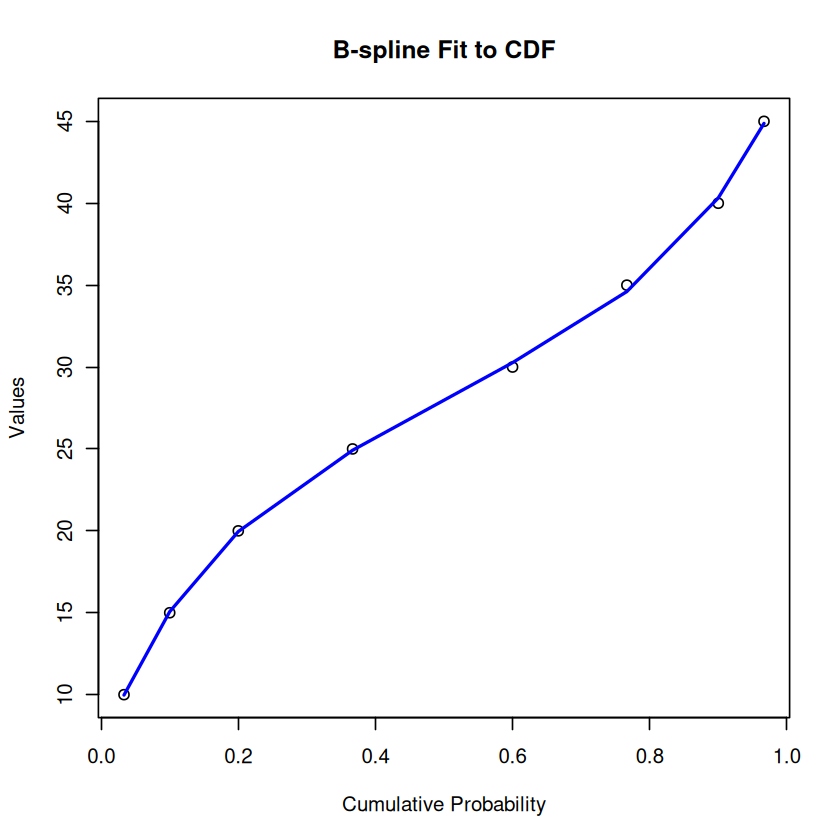

In [30]:
plot(probs, vals, main = "B-spline Fit to CDF", xlab = "Cumulative Probability", ylab = "Values")
lines(probs, predict(b_spline_fit), col = "blue", lwd = 2)

In [42]:
# Get the predicted values from the fitted B-spline
pred_values <- predict(b_spline_fit, newdata = data.frame(probs = probs))

In [44]:
class(pred_values)

[1] "numeric"

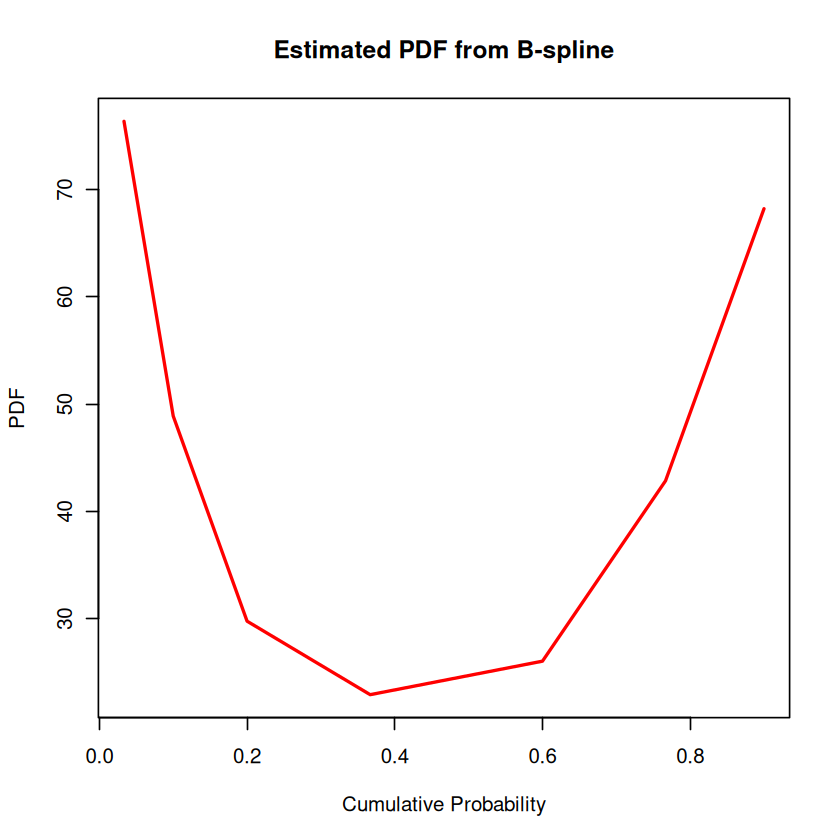

In [45]:
# Differentiate to get the PDF (numerically approximate the derivative)
pdf_values <- diff(pred_values) / diff(probs)  # Approximate derivative (finite difference)

# Plot the estimated PDF
plot(probs[-length(probs)], pdf_values, main = "Estimated PDF from B-spline", xlab = "Cumulative Probability", ylab = "PDF", type = "l", col = "red", lwd = 2)

In [47]:
#Numerically integrate the PDF over the cumulative probability range [0, 1]
integrated_pdf <- sum(pdf_values * diff(probs))  # Approximating the integral using the trapezoidal rule

# Check if the integral is close to 1
cat("Integral of PDF:", integrated_pdf, "\n")

Integral of PDF: 34.8957 


In [48]:
normalization_factor <- 1 / integrated_pdf

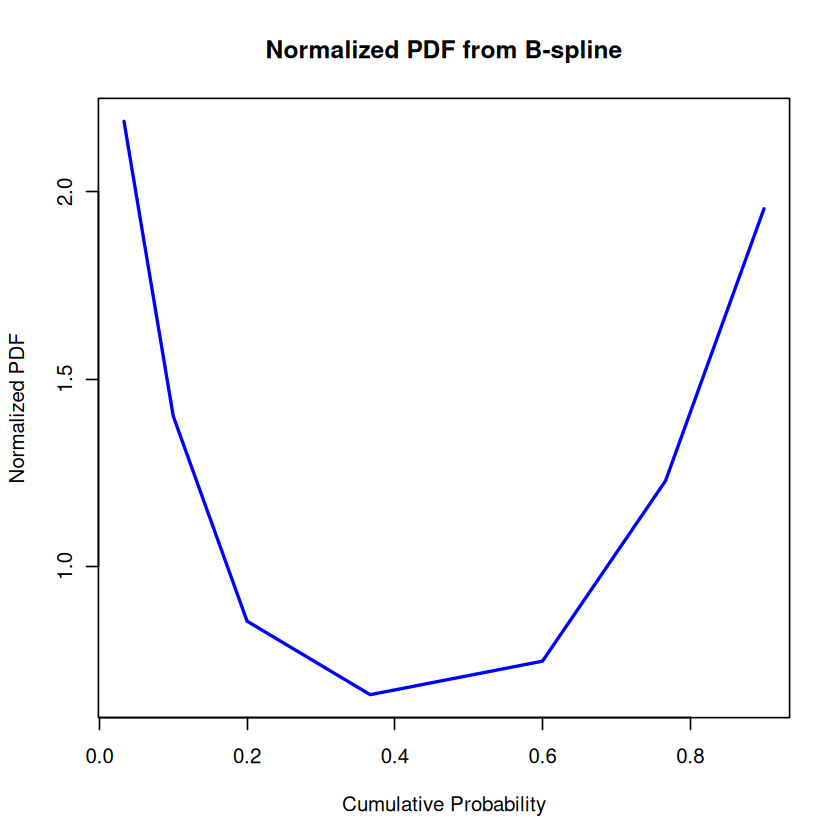

In [49]:
# Normalize the PDF by the normalization factor
normalized_pdf_values <- pdf_values * normalization_factor

# Plot the normalized PDF
plot(probs[-length(probs)], normalized_pdf_values, main = "Normalized PDF from B-spline", xlab = "Cumulative Probability", ylab = "Normalized PDF", type = "l", col = "blue", lwd = 2)

In [50]:
# Numerically integrate the normalized PDF over the cumulative probability range [0, 1]
normalized_integral <- sum(normalized_pdf_values * diff(probs))

# Check if the integral is close to 1 (should be close now)
cat("Integral of Normalized PDF:", normalized_integral, "\n")

Integral of Normalized PDF: 1 


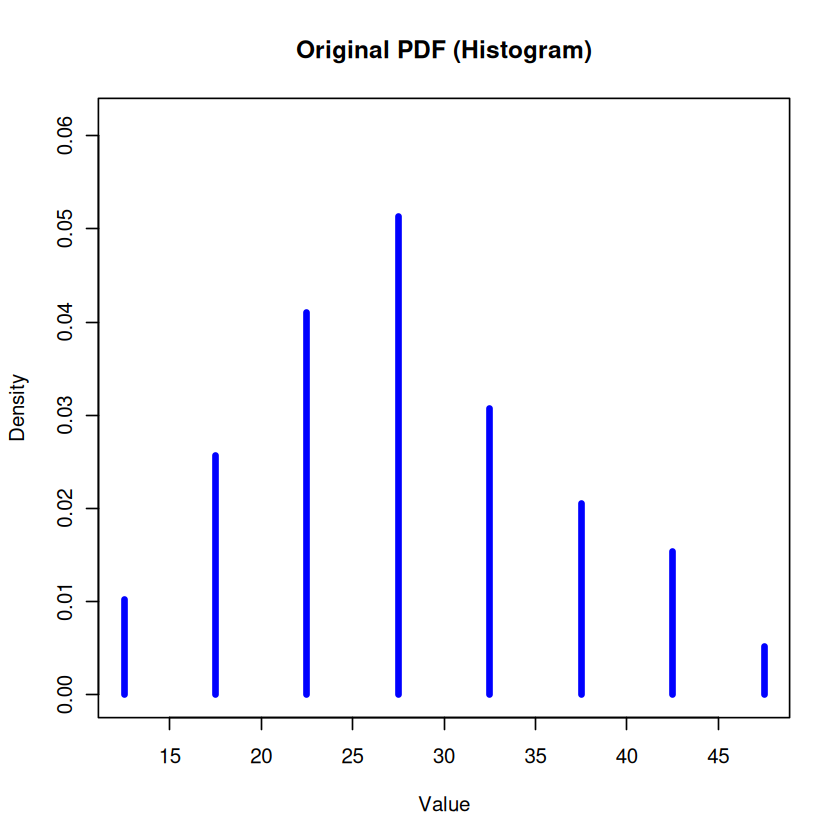

In [53]:
# Example bin edges and frequencies (replace with your actual histogram data)
bin_edges <- c(10, 15, 20, 25, 30, 35, 40, 45, 50)  # Bin edges
bin_counts <- c(2, 5, 8, 10, 6, 4, 3, 1)  # Histogram counts

# Normalize bin counts to get a probability density (PDF)
bin_widths <- diff(bin_edges)
pdf_values <- bin_counts / (sum(bin_counts) * bin_widths)  # Convert counts to density

# Compute midpoints of bins
bin_midpoints <- (bin_edges[-length(bin_edges)] + bin_edges[-1]) / 2

# Plot the original histogram as the PDF
plot(bin_midpoints, pdf_values, type = "h", lwd = 4, col = "blue",
     xlab = "Value", ylab = "Density", main = "Original PDF (Histogram)",
     ylim = c(0, max(pdf_values) * 1.2))

# Fitting b-spline

In [36]:
# Step 1: Define cumulative probabilities and bin edges
cumsums <- c(0.05, 0.15, 0.35, 0.6, 0.8, 0.95)
vals <- c(3, 4, 5, 6, 7, 8)  # Bin edges

In [37]:
vals_extended <- c(0, vals, 20)
cumsums_extended <- c(0, cumsums, 1)

In [38]:
library(splines2)

In [50]:
# Step 2: Fit B-spline to the CDF data using bSpline from splines2
spline_fit <- lm(cumsums ~ bSpline(vals, degree = 4, Boundary.knots = c(0, 20)))

# View the model summary
summary(spline_fit)


Call:
lm(formula = cumsums ~ bSpline(vals, degree = 4, Boundary.knots = c(0, 
    20)))

Residuals:
         1          2          3          4          5          6 
-0.0005952  0.0029762 -0.0059524  0.0059524 -0.0029762  0.0005952 

Coefficients:
                                                      Estimate Std. Error
(Intercept)                                             1.6446     0.7635
bSpline(vals, degree = 4, Boundary.knots = c(0, 20))1  -6.5317     3.1194
bSpline(vals, degree = 4, Boundary.knots = c(0, 20))2  10.0615     5.9854
bSpline(vals, degree = 4, Boundary.knots = c(0, 20))3 -15.4980    18.6668
bSpline(vals, degree = 4, Boundary.knots = c(0, 20))4  18.1786    43.9745
                                                      t value Pr(>|t|)
(Intercept)                                             2.154    0.277
bSpline(vals, degree = 4, Boundary.knots = c(0, 20))1  -2.094    0.284
bSpline(vals, degree = 4, Boundary.knots = c(0, 20))2   1.681    0.342
bSpline(vals, degree =

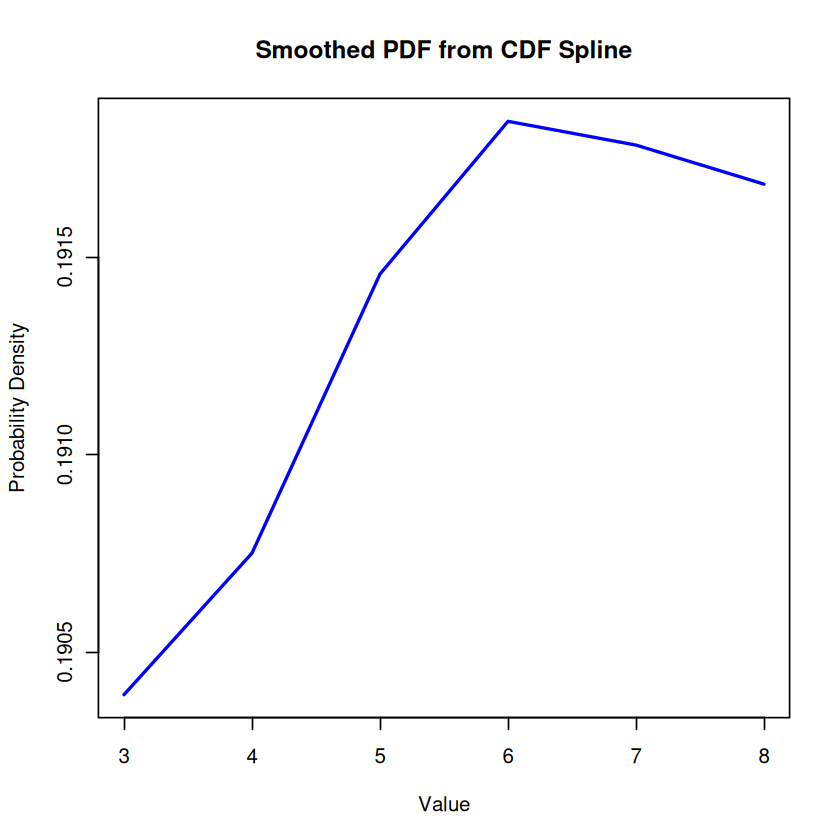

In [52]:
# Step 2: Fit a smooth spline to the CDF
cdf_spline_fit <- smooth.spline(vals, cumsums, spar = 0.7)

# Derive the PDF by differentiating the CDF spline
pdf_values_spline <- predict(cdf_spline_fit, x = vals, deriv = 1)$y

# Plot the smoothed PDF derived from the CDF spline
plot(vals, pdf_values_spline, type = "l", col = "blue", lwd = 2, 
     xlab = "Value", ylab = "Probability Density", 
     main = "Smoothed PDF from CDF Spline")

In [56]:
# Fit a B-spline to the CDF values (cumsums)
library(splines2)
cdf_bspline_fit <- bSpline(vals, degree = 3, intercept = TRUE)

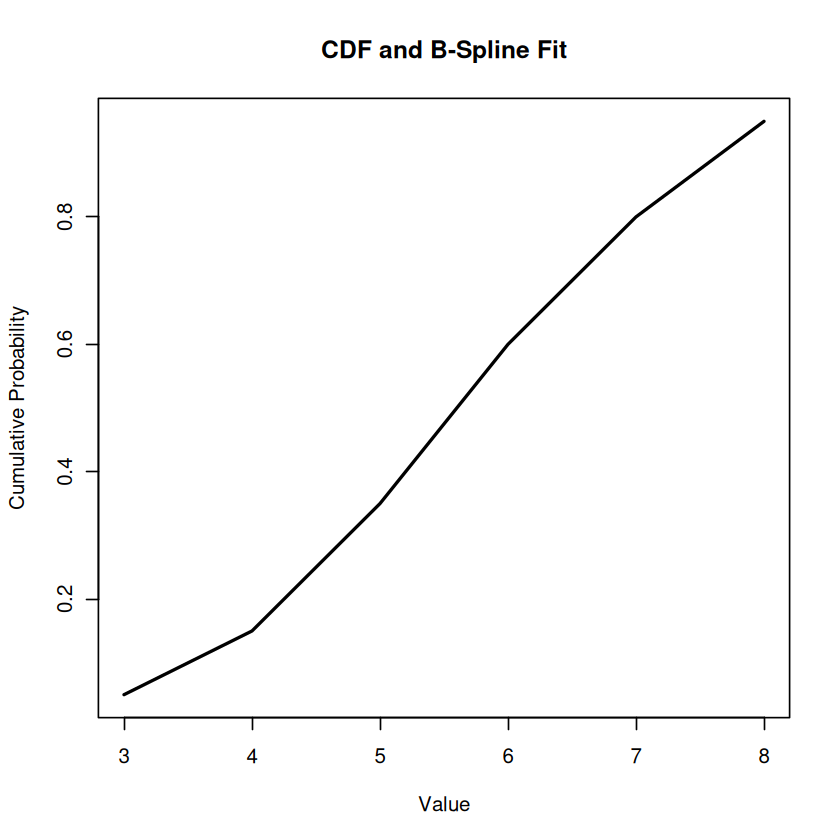

In [58]:
# Plot the CDF and its B-spline fit
plot(vals, cumsums, type = "l", col = "black", lwd = 2,
     xlab = "Value", ylab = "Cumulative Probability",
     main = "CDF and B-Spline Fit")
#lines(vals, cdf_bspline_fit %*% coef(lm(cumsums ~ cdf_bspline_fit)), col = "blue", lwd = 2)

In [59]:
# Evaluate the B-spline fit at the points in vals
cdf_bspline_values <- predict(cdf_bspline_fit, x = vals)

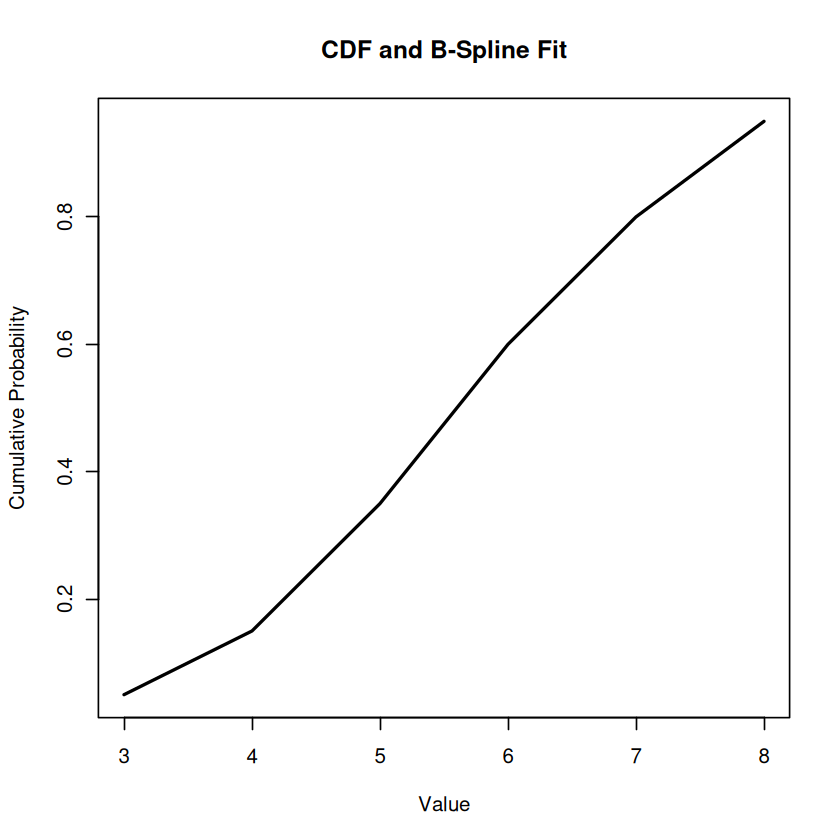

In [60]:
# Plot the original CDF
plot(vals, cumsums, type = "l", col = "black", lwd = 2,
     xlab = "Value", ylab = "Cumulative Probability",
     main = "CDF and B-Spline Fit")

# Add the B-spline fit to the plot
lines(vals, cdf_bspline_values$y, col = "blue", lwd = 2)  # $y gives the fitted values

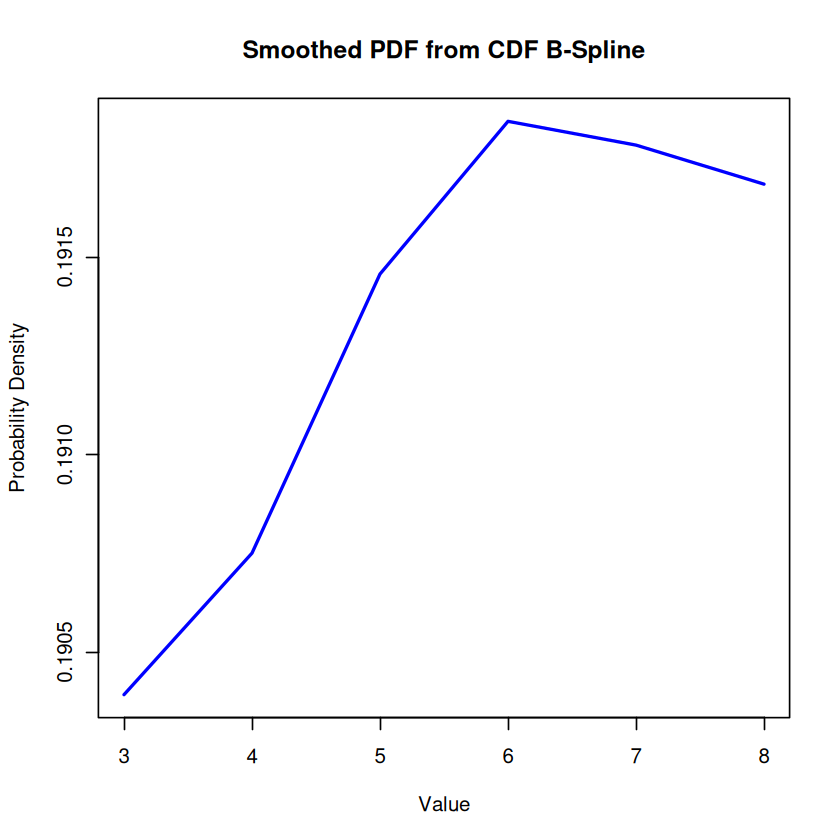

In [54]:
# Derive the PDF by differentiating the CDF spline
pdf_values_spline <- predict(cdf_spline_fit, x = vals, deriv = 1)$y

# Plot the derived PDF
plot(vals, pdf_values_spline, type = "l", col = "blue", lwd = 2,
     xlab = "Value", ylab = "Probability Density", 
     main = "Smoothed PDF from CDF B-Spline")

In [63]:
# Derive the PDF by differentiating the B-spline fit (CDF)
cdf_bspline_derivative <- diff(cdf_bspline_values$y) / diff(vals)

# Plot the derived PDF
plot(vals[-1], cdf_bspline_derivative, type = "l", col = "blue", lwd = 2,
     xlab = "Value", ylab = "Probability Density", 
     main = "Smoothed PDF from B-Spline")

ERROR: Error in xy.coords(x, y, xlabel, ylabel, log): 'x' and 'y' lengths differ


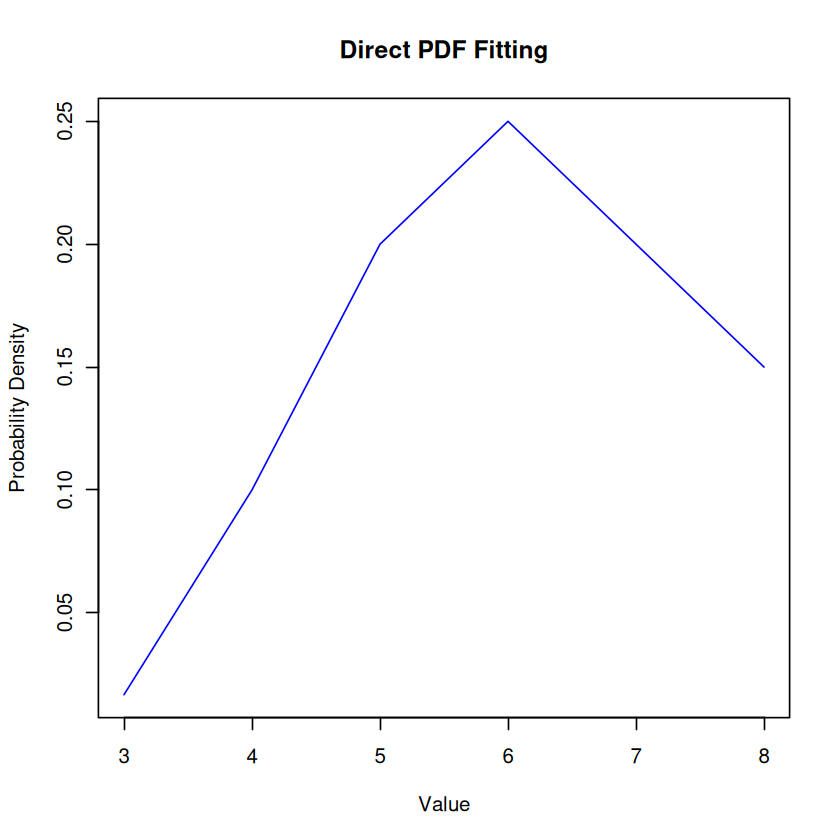

In [51]:
# Step 2: Compute the PDF directly from the CDF (using the difference in values)
pdf_values_direct <- diff(c(0, cumsums)) / diff(c(0, vals))  # Adding 0 at the start for proper diff

# Plot the direct PDF
plot(vals, pdf_values_direct, type = "l", col = "blue", 
     xlab = "Value", ylab = "Probability Density", 
     main = "Direct PDF Fitting")

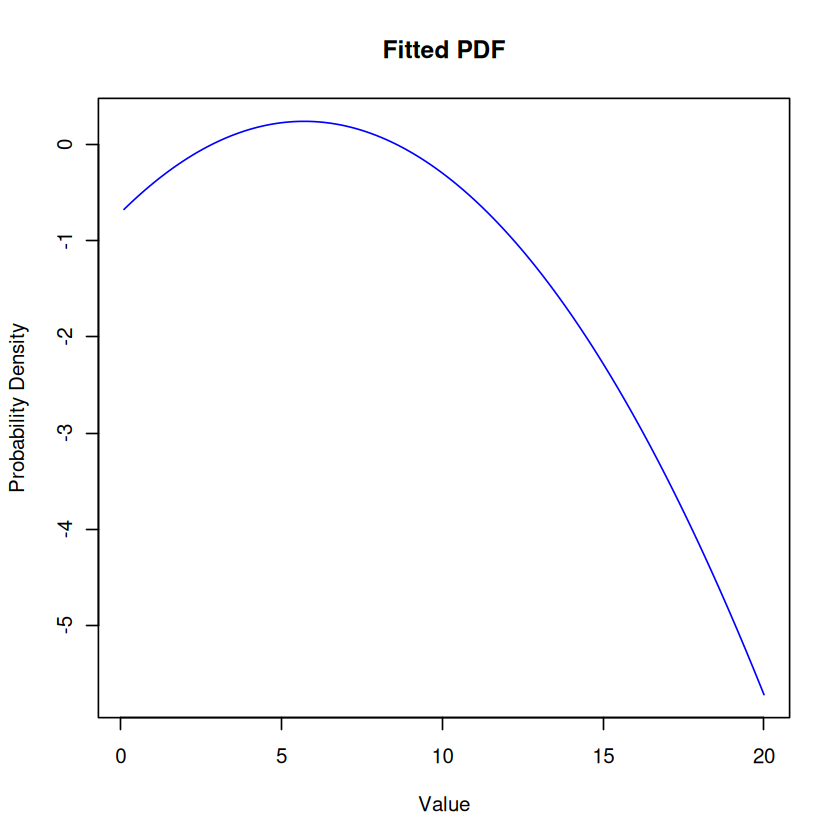

In [42]:
# Step 3: Generate predicted values for the spline (CDF)
pred_values <- predict(spline_fit, newdata = data.frame(vals = seq(0, 20, by = 0.1)))

# Compute the PDF as the derivative of the CDF
pdf_values <- diff(pred_values) / 0.1  # Divide by step size (0.1)

# Plot the PDF
plot(seq(0.1, 20, by = 0.1), pdf_values, type = "l", col = "blue", 
     xlab = "Value", ylab = "Probability Density", main = "Fitted PDF")

In [46]:
vals

[1] 3 4 5 6 7 8

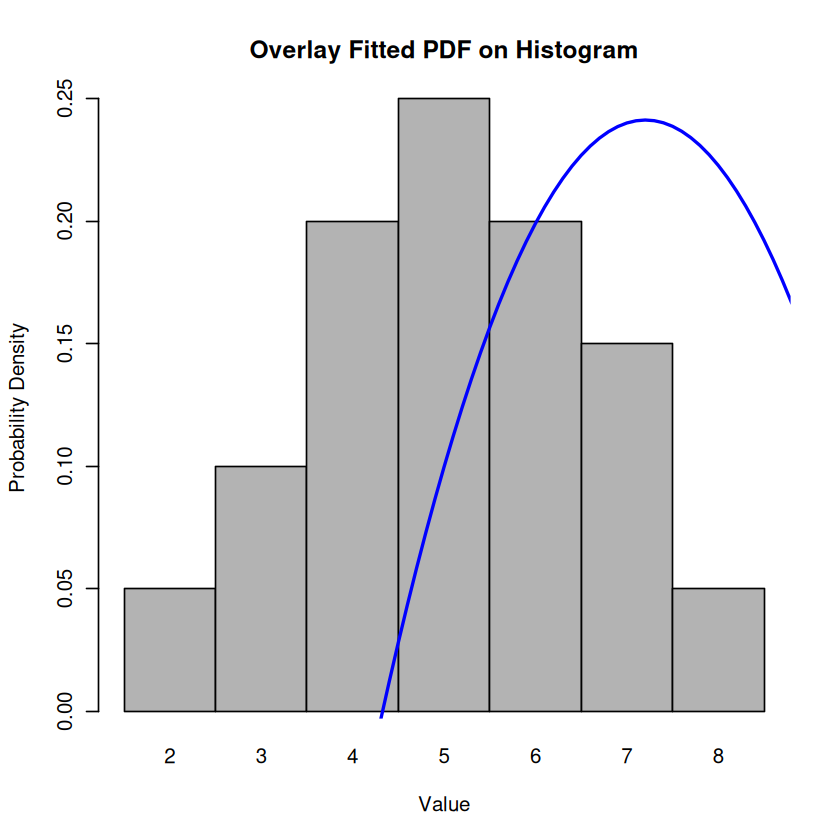

In [48]:
# Step 4: Plot the original PDF as a barplot (representing original histogram)
barplot(pdf_heights, names.arg = c("2",vals), space = 0, width = 1, 
        col = rgb(0.7, 0.7, 0.7), border = "black", 
        main = "Overlay Fitted PDF on Histogram", 
        xlab = "Value", ylab = "Probability Density")
lines(seq(0.1, 20, by = 0.1), pdf_values, col = "blue", lwd = 2)

In [13]:
# Generate a sequence of x-values to evaluate the CDF
x_seq <- seq(0, 20, length.out = 100)

In [14]:
# Predict the CDF using the fitted model
pred_cdf <- predict(cdf_fit, newdata = data.frame(bs_basis = bSpline(x_seq, knots = knots, degree = 3, intercept = TRUE)))

Warning message:
“'newdata' had 100 rows but variables found have 8 rows”


In [15]:
# Compute PDF by differentiating the CDF
pdf_values <- diff(pred_cdf) / diff(x_seq)  # Approximate derivative
pdf_x <- head(x_seq, -1)  # Adjust x-values for PDF plot

Warning message in diff(pred_cdf)/diff(x_seq):
“longer object length is not a multiple of shorter object length”


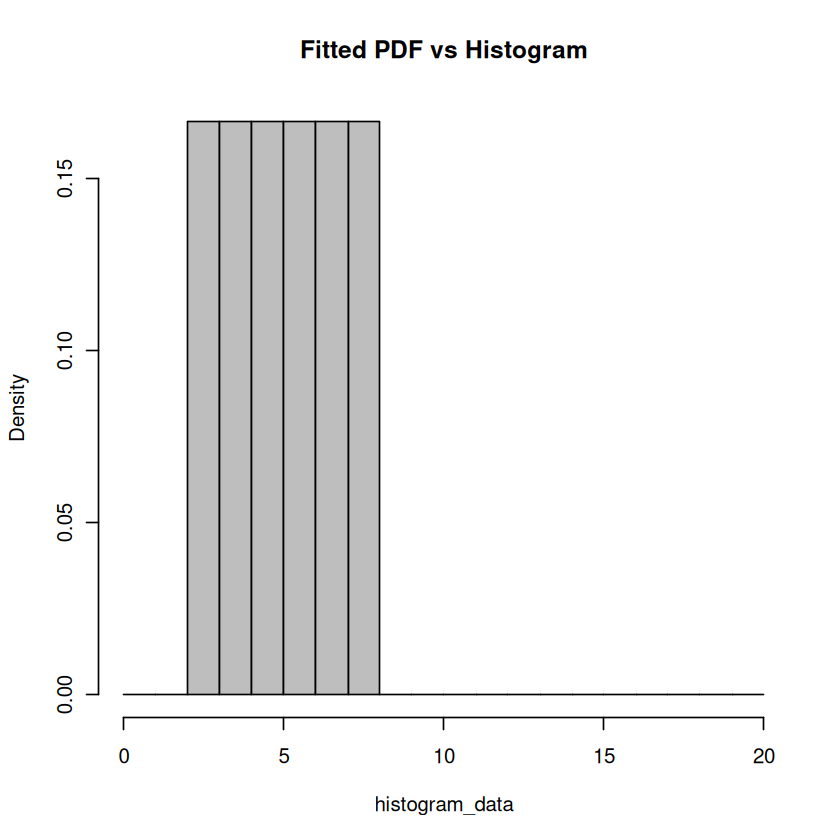

In [16]:
# Histogram (assuming histogram_data contains the original histogram)
histogram_data <- c(3, 4, 5, 6, 7, 8)  # Example bin centers
hist(histogram_data, probability = TRUE, col = "gray", border = "black", breaks = seq(0, 20, by = 1), main = "Fitted PDF vs Histogram")

# Overlay the fitted PDF
lines(pdf_x, pdf_values, col = "red", lwd = 2)

In [6]:
pdf_heights <- diff(c(0, cumsums, 1))  # Get probability mass in each bin
bin_centers <- c(3.5, 4.5, 5.5, 6.5, 7.5, 8.5)  # Midpoints of bins

ERROR: Error in barplot.default(pdf_heights, names.arg = bin_centers, space = 0, : incorrect number of names


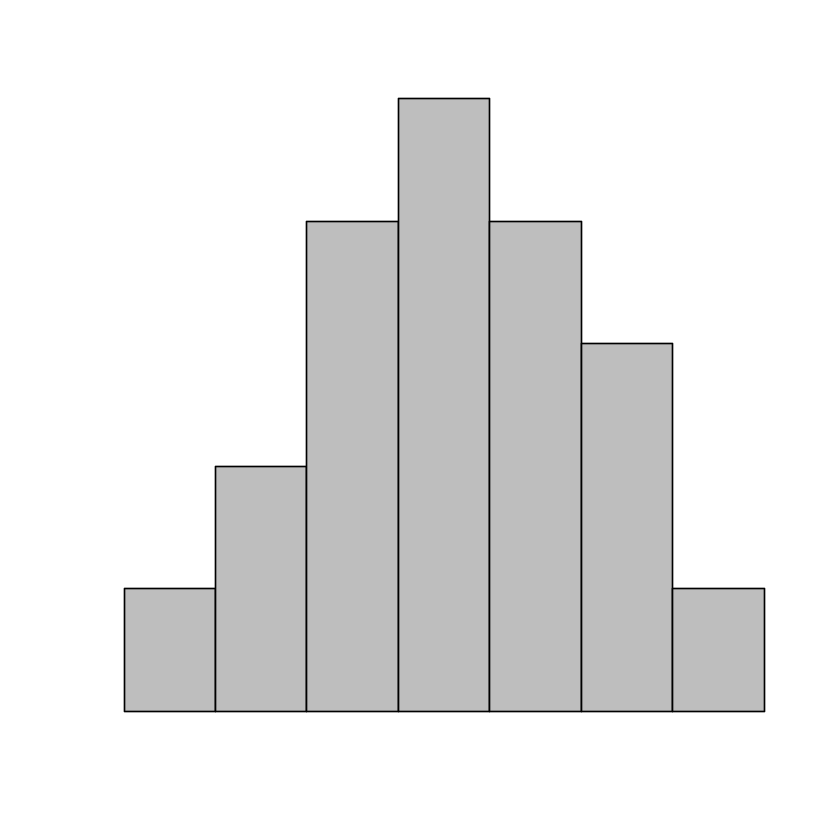

In [10]:
# Given cumulative probabilities
cumsums <- c(0.05, 0.15, 0.35, 0.6, 0.8, 0.95)
vals <- c(3, 4, 5, 6, 7, 8)

# Compute probability density for each bin
pdf_heights <- diff(c(0, cumsums, 1))  # Probability mass in each bin

# Define bin midpoints (match number of pdf_heights)
bin_centers <- vals  # Use actual bin edges, NOT midpoints

# Define bin widths (assuming equal bins of width 1)
bin_widths <- rep(1, length(pdf_heights))

# Plot histogram using barplot()
barplot(pdf_heights, names.arg = bin_centers, space = 0, width = bin_widths,
        col = "gray", border = "black", main = "Original Histogram (PDF)",
        xlab = "Value", ylab = "Probability Density"

ERROR: Error in barplot.default(pdf_heights, names.arg = bin_centers, space = 0, : incorrect number of names


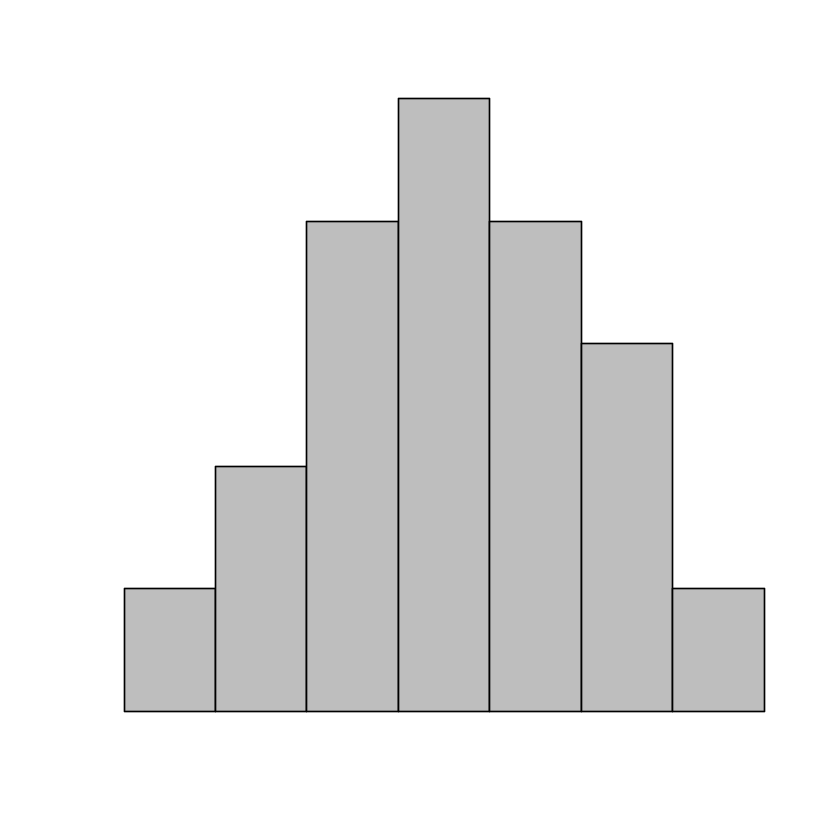

In [4]:
pdf_heights <- diff(c(0, cumsums, 1))  # Get probability mass in each bin
bin_centers <- c(3.5, 4.5, 5.5, 6.5, 7.5, 8.5)  # Midpoints of bins

In [56]:
# Compute CDF values by cumulative sum
cdf_values <- cumsum(pdf_values * bin_widths)

In [57]:
cdf_values

[1] 0.05128205 0.17948718 0.38461538 0.64102564 0.79487179 0.89743590 0.97435897
[8] 1.00000000

In [ ]:
      # starting values: c(m, log((u - m)/ qt(0.6, tdf[i])))
      
      tFit <- optim(c(m, 0.5*log(v)), tError, 
                     values = vals[inc,i], 
                     probabilities = probs[inc,i], 
                     weights = weights[inc,i], 
                     degreesfreedom = tdf[i])
      tParameters[i, 1:2] <- c(tFit$par[1], exp(tFit$par[2]))
      tParameters[i, 3] <- tdf[i]
      ssq[i, "t"] <- tFit$value
      

[1] 0.05128205 0.17948718 0.38461538 0.64102564 0.79487179 0.89743590 0.97435897
[8] 1.00000000

ERROR: Error in eval(expr, envir, enclos): object 'tError' not found


In [ ]:
      # skew normal fit ----
      # will fit 3 parameters in skew normal, so need at least 3 judgements
      if(length(vals[inc, i]) > 2){
        
        # Fit in two stages. First, optimise for location and scale, over
        # fixed grid of shape/slant parameters
        
        alphaVec <- c(-20, -10, -5:5, 10, 20)
        delta <- alphaVec / sqrt(1 + alphaVec^2)
        eVec <- rep(0, 15)
        
        # Get starting values by matching moments to fitted normal distribution
        omegaStart <- normal.parameters[i,2] / sqrt(1 - 2*delta^2/pi)
        xiStart <- normal.parameters[i,1] - omegaStart * delta*sqrt(2/pi)
        for(j in 1:15){
          
          eVec[j]<- optim(c(xiStart[j], log(omegaStart[j])), 
                          skewnormal.error, values = vals[inc, i], 
                          probabilities = probs[inc,i], 
                          weights = weights[inc,i],
                          snAlpha = alphaVec[j])$value

        }
        
        # Now find best fit, and optimise over all three parameters, starting
        # from that best fit
        
        index <- which.min(eVec)
        skewnormal.fit <- optim(c(xiStart[index], log(omegaStart[index]),
                                    alphaVec[index]), 
                                  skewnormal.error.joint,
                                values = vals[inc, i], 
                                  probabilities = probs[inc,i], 
                                  weights = weights[inc,i])
      
      skewnormal.parameters[i,] <- c(skewnormal.fit$par[1],
                                     exp(skewnormal.fit$par[2]),
                                     skewnormal.fit$par[3])
      ssq[i, "skewnormal"] <- skewnormal.fit$value
      
      }
      # Positive skew distribution fits ----
      
      
      if(lower[i] > -Inf){
        vals.scaled1 <- vals[inc,i] - lower[i]
        m.scaled1 <- m - lower[i]
        
        gamma.fit<-optim(c(log(m.scaled1^2/v), log(m.scaled1/v)), 
                         gamma.error, values = vals.scaled1, 
                         probabilities = probs[inc,i], 
                         weights = weights[inc,i])
        gamma.parameters[i,] <- exp(gamma.fit$par)
        ssq[i, "gamma"] <- gamma.fit$value
        
        std<-((log(u - lower[i])-log(l - lower[i]))/1.35)
        
        # mlog <- (log(minvals - lower[i]) * 
        #            maxq - log(maxvals - lower[i]) * minq) /
        #   (maxq - minq)
        
        lognormal.fit <- optim(c(mlog,
                                 log(std)), 
                               lognormal.error, 
                               values = vals.scaled1, 
                               probabilities = probs[inc,i], 
                               weights = weights[inc,i])
        lognormal.parameters[i, 1:2] <- c(lognormal.fit$par[1],
                                          exp(lognormal.fit$par[2]))
        ssq[i, "lognormal"] <- lognormal.fit$value
        
        logt.fit <- optim(c(log(m.scaled1), log(std)), 
                          logt.error, 
                          values = vals.scaled1, 
                          probabilities = probs[inc,i], 
                          weights = weights[inc,i], 
                          degreesfreedom = tdf[i])
        logt.parameters[i,1:2] <- c(logt.fit$par[1], exp(logt.fit$par[2]))
        logt.parameters[i,3] <- tdf[i]
        ssq[i, "logt"] <- logt.fit$value
      }
      
      # Beta distribution fits ----
      
      if((lower[i] > -Inf) & (upper[i] < Inf)){
        vals.scaled2 <- (vals[inc,i] - lower[i]) / (upper[i] - lower[i])
        m.scaled2 <- (m - lower[i]) / (upper[i] - lower[i])
        v.scaled2 <- v / (upper[i] - lower[i])^2
        
        alp <- abs(m.scaled2 ^3 / v.scaled2 * (1/m.scaled2-1) - m.scaled2)
        bet <- abs(alp/m.scaled2 - alp)
        if(identical(probs[inc, i], 
                     (vals[inc, i] - lower[i]) / (upper[i] - lower[i]))){
          alp <- bet <- 1
        }
        beta.fit <- optim(c(log(alp), log(bet)), 
                          beta.error, 
                          values = vals.scaled2, 
                          probabilities = probs[inc,i], 
                          weights = weights[inc,i])
        beta.parameters[i,] <- exp(beta.fit$par)
        ssq[i, "beta"] <- beta.fit$value	
        
      }
      
      # Negative skew distribution fits ----
      
      if(upper[i] < Inf){
        
        # Distributions are fitted to Y:= Upper limit - X
        
        valsMirrored <- upper[i] - vals[inc, i]
        probsMirrored <- 1 - probs[inc, i]
        mMirrored <- upper[i] - m
        
        # Mirror gamma
        
        
        
        mirrorgamma.fit<-optim(c(log(mMirrored^2/v), log(mMirrored/v)), 
                               gamma.error, values = valsMirrored, 
                               probabilities = probsMirrored, 
                               weights = weights[inc,i])
        mirrorgamma.parameters[i,] <- exp(mirrorgamma.fit$par)
        ssq[i, "mirrorgamma"] <- mirrorgamma.fit$value
        
        # Mirror log normal
        
        
        # Obtain mlogMirror by solving simultaneously:
        # m + Z_l \sqrt{v} = Y_l
        # m + Z_u \sqrt{v} = Y_u
        # where Z_a is a-th quantile from N(0, 1),
        # Y_a is a-th quantile of Y
        # and we model Y = log(upper - X) ~ N(mlogMirror, stdMirror^2)
        
        
        # mlogMirror <- (log(upper[i] - maxvals) * 
        #                  (1 - minq) -
        #                  log(upper[i] - minvals) * (1-maxq)) /
        #   (maxq - minq)
        
        stdMirror <-((log(upper[i] - l)-log(upper[i] - u))/1.35)
        
        
        mirrorlognormal.fit <- optim(c(mlogMirror,
                                       log(stdMirror)), 
                                     lognormal.error, 
                                     values = valsMirrored, 
                                     probabilities = probsMirrored, 
                                     weights = weights[inc,i])
        mirrorlognormal.parameters[i, 1:2] <-
          c(mirrorlognormal.fit$par[1],
            exp(mirrorlognormal.fit$par[2]))
        ssq[i, "mirrorlognormal"] <- mirrorlognormal.fit$value
        
        # Mirror log t
        
        mirrorlogt.fit <- optim(c(log(mMirrored), log(stdMirror)), 
                          logt.error, 
                          values = valsMirrored, 
                          probabilities = probsMirrored, 
                          weights = weights[inc,i], 
                          degreesfreedom = tdf[i])
        mirrorlogt.parameters[i,1:2] <- c(mirrorlogt.fit$par[1],
                                          exp(mirrorlogt.fit$par[2]))
        mirrorlogt.parameters[i,3] <- tdf[i]
        ssq[i, "mirrorlogt"] <- mirrorlogt.fit$value
        
      }
       }else{
         notes <- paste0("Did not have smallest elicited probability < 0.4 and > 0, ",
                         "and largest > 0.6 and < 1. If lower and/or upper limits specified, ",
                         "gamma and mirror gamma are fitted with the shape ",
                         "parameter fixed at 1, i.e. an exponential distribution.")
        
         # Exponential fit ----
         
         # If only a single probability specified, or probabilities 
         # too close to 0.5, will fit a gamma with shape parameter = 1
         # via fitting an exponential distribution
         
         if(lower[i] > -Inf){
           lambda <- -log(1 - maxprob)/(maxvals - lower[i])
           exponential.fit <- optimise(exponential.error,
                                       interval = c(0, 2 * lambda),
                                       values = vals[inc,i] - lower[i],
                                       probabilities = probs[inc,i], 
                                       weights = weights[inc,i])   
           gamma.parameters[i,] <- c(1, exponential.fit$minimum)
           ssq[i, "gamma"] <- exponential.fit$objective
           
         }
         
         if(upper[i] < Inf){
           lambda <- -log(minprob)/(upper[i] - minvals)
           mirrorexponential.fit <- optimise(exponential.error,
                                       interval = c(0, 2 * lambda),
                                       values = upper[i] - vals[inc, i],
                                       probabilities = 1 - probs[inc,i], 
                                       weights = weights[inc,i])   
           mirrorgamma.parameters[i,] <- c(1, mirrorexponential.fit$minimum)
           ssq[i, "mirrorgamma"] <- mirrorexponential.fit$objective
           
         }
          
       }
      
      
      
    }

  n.experts <- ncol(vals)
  n_coef_max <- 10 # Maximum number of coefficients we expect (adjust as needed)
  bspline.parameters <- matrix(NA, nrow = 0, ncol = 0) # Initialize BEFORE the loop

  # ... inside the loop (for(i in 1:n.experts)) ...

  # B-spline fit
  if(length(vals[inc, i]) > 2){ # Need at least 3 points for a cubic spline
    n_knots <- min(length(unique(vals[inc, i])) - 1, 6) # knots <= number of unique x-values - 1, max 6
    if (n_knots < 3) {n_knots <- 3} # Need at least 3 knots for a cubic spline

    # Handle cases where all values are the same:
    if(length(unique(vals[inc,i])) == 1){
      warning(paste("All x-values are identical for expert", i, ". Cannot fit B-spline."))
      bspline.parameters[i,] <- NA
      ssq[i, "bspline"] <- NA
    } else {
      b_spline_basis <- splines::bs(vals[inc, i], knots = quantile(vals[inc, i], probs = seq(0, 1, length.out = n_knots + 1)[2:(n_knots)]), degree = 3, intercept = TRUE) #cubic spline
      n_coef <- ncol(b_spline_basis) # Actual number of coefficients
      b_spline_fit <- lm(probs[inc, i] ~ b_spline_basis, weights = weights[inc, i]) # Linear regression to get coefficients
      
      coefs <- coef(b_spline_fit)
      coef_names <- names(coefs)
      
   bspline.parameters<-as.matrix(t(coefs[-1]))
      ssq[i, "bspline"] <- sum(b_spline_fit$residuals^2*weights[inc, i])
    }

  } else {
    bspline.parameters[i,] <- NA # Fill with NA if not enough points
    ssq[i, "bspline"] <- NA
  }
  # ... end of the loop ...

  dfbs <- data.frame(bspline.parameters)
  row.names(dfbs) <- expertnames
      
    dfn <- data.frame(normal.parameters)
    names(dfn) <-c ("mean", "sd")
    row.names(dfn) <- expertnames
    
    dfsn <- data.frame(skewnormal.parameters)
    names(dfsn) <-c ("location", "scale" , "slant")
    row.names(dfsn) <- expertnames
    
    dft <- data.frame(tParameters)
    names(dft) <-c ("location", "scale", "df")
    row.names(dft) <- expertnames
    
    dfg <- data.frame(gamma.parameters)
    names(dfg) <-c ("shape", "rate")
    row.names(dfg) <- expertnames
    
    dfmirrorg <- data.frame(mirrorgamma.parameters)
    names(dfmirrorg) <-c ("shape", "rate")
    row.names(dfmirrorg) <- expertnames
    
    dfln <- data.frame(lognormal.parameters)
    names(dfln) <-c ("mean.log.X", "sd.log.X")
    row.names(dfln) <- expertnames
    
    dfmirrorln <- data.frame(mirrorlognormal.parameters)
    names(dfmirrorln) <-c ("mean.log.X", "sd.log.X")
    row.names(dfmirrorln) <- expertnames
    
    dflt <- data.frame(logt.parameters)
    names(dflt) <-c ("location.log.X", "scale.log.X", "df.log.X")
    row.names(dflt) <- expertnames
    
    dfmirrorlt <- data.frame(mirrorlogt.parameters)
    names(dfmirrorlt) <-c ("location.log.X", "scale.log.X", "df.log.X")
    row.names(dfmirrorlt) <- expertnames
    
    dfb <- data.frame(beta.parameters)
    names(dfb) <-c ("shape1", "shape2")
    row.names(dfb) <- expertnames
    
    ssq <- data.frame(ssq)
    row.names(ssq) <- expertnames
    
    if(excludelogt){
      reducedssq <- ssq[, c("normal", "t", "skewnormal", "gamma",
                              "lognormal", "beta", 
                              "mirrorgamma",
                              "mirrorlognormal","bspline")]
      index <- apply(reducedssq, 1, which.min)
      best.fitting <- data.frame(best.fit=
                                   names(reducedssq)[index])}else{
      index <- apply(ssq, 1, which.min)
      best.fitting <- data.frame(best.fit=names(ssq)[index])
      }
      
  
    
    row.names(best.fitting) <- expertnames
    
    vals <- data.frame(vals)
    names(vals) <- expertnames
    
    probs <- data.frame(probs)
    names(probs) <- expertnames
    fit <- list(Normal = dfn, Student.t = dft, Skewnormal = dfsn, 
                Gamma = dfg, Log.normal = dfln, 
                Log.Student.t = dflt, Beta = dfb,
                mirrorgamma = dfmirrorg,
                mirrorlognormal = dfmirrorln,
                mirrorlogt = dfmirrorlt,
                bspline = dfbs,
                ssq = ssq, 
                best.fitting = best.fitting, vals = t(vals), 
                probs = t(probs), limits = limits, 
                notes = notes)
    class(fit) <- "elicitation"
    fit
  }